# US Revenue Growth Ranking Analysis v2

`us_revenue_analysis_notebook`(단일 티커 조회·차트·Best-N 차트) + `us_revenue_growth_ranking_analysis_v1`(TTM 전체 순위·Excel 추출) 병합본

**소스 테이블** : `us_revenue_forecast_data`  
**출력 파일**   : `C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가\us_revenue_growth_analysis_{YYYYMMDD}.xlsx` (+ Best-N 차트 PNG)

### 성장률 정의
| 구분 | 계산 |
|---|---|
| **yoy_growth (4Q)** | Σ 예측 Q+1~Q+4 ÷ Σ 직전 실제 4Q − 1 (Forward TTM / TTM) |
| **growth_8q** | Σ 예측 8Q ÷ Σ 최근 실제 8Q − 1 |
| **CAGR** | (예측 마지막값 / 실제 마지막값)^(4/예측분기수) − 1 |
| **rank** | 전체 유효 종목 기준 yoy_growth 내림차순 |

---
| 셀 | 단계 | 구분 |
|---|---|---|
| Cell 1 | 환경 설정 & 경로 자동 감지 | 공통 |
| Cell 2 | **Control Panel** (여기만 수정) | 공통 |
| Cell 3 | Import & DB 연결 | 공통 |
| Cell 4 | 핵심 계산 함수 | 공통 |
| Cell 5 | 단일 티커 예측치 조회 `fetch_forecast` | A. 단일 티커 |
| Cell 6 | 단일 티커 요약 + QoQ/누적 CAGR 표 | A. 단일 티커 |
| Cell 7 | 단일 티커 매출 전망 차트 `plot_ticker_forecast` | A. 단일 티커 |
| Cell 8 | 전체 종목 조회 · TTM 성장률 · 전체 순위 | B. 전체 순위 |
| Cell 9 | 회사명 매핑 (FMP profile + CSV 캐시) | B. 전체 순위 |
| Cell 10 | Excel 저장 (Summary/Detail/Excluded/Meta) | B. 전체 순위 |
| Cell 11 | **실행** — 추출 → 회사명 → 저장 → 미리보기 | B. 전체 순위 |
| Cell 12 | Best-N 추출 + 4Q/8Q 비교 막대 차트 | C. Best-N 차트 |
| Cell 13 | 특정 종목 순위 확인 | 조회 |


## Cell 1 · 환경 설정 & 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve()
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root (자동 감지): {root}")
            return root
    for c in _CANDIDATE_ROOTS:
        if os.path.isdir(c):
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f"[PATH] root (후보 경로): {c}")
            return c
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS를 수정하세요.")

_root = _setup_path()
print(f"[확인] sys.path[0] = {sys.path[0]}")


[PATH] root (자동 감지): C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] sys.path[0] = C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\US_Market\analysis\미국전기업_매출_예측


## Cell 2 · Control Panel

이 셀만 수정해서 모델·단위·저장 위치·필터·차트 설정을 바꿉니다.

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  Control Panel — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════════

# ── 소스 ─────────────────────────────────────────────────────────────
SRC_TABLE  = "us_revenue_forecast_data"
ITEM       = "sale"
MODEL      = "Ensemble"          # SARIMA / ETS / Theta / Ensemble

# ── forecast_date 선택 ────────────────────────────────────────────────
#   None          : 티커별 가장 최근 forecast_date 자동 선택 (권장)
#                   → 어닝 시점이 달라 예측일이 다른 종목도 모두 포함
#   ["2026-08-03"]: 지정한 날짜(들)만 사용, 같은 티커가 여러 날짜면 최신만 유지
FORECAST_DATES = None

# ── 금액 단위 ─────────────────────────────────────────────────────────
UNIT_DIVISOR = 1e6               # 1e6 → $M,  1e9 → $B,  1 → $
UNIT_LABEL   = "$M"

# ── 필터 (Summary 에서 제외) ──────────────────────────────────────────
MIN_REVENUE_TTM = 0              # 원단위($) 기준. 예: 50e6 → TTM 매출 5천만 달러 미만 제외
EXCLUDE_TICKERS = [              # 중복 티커·상장폐지 등 알려진 데이터 품질 이슈 종목
    # "VVX", "FI", "WLYB", "GPS", "OPLN", "SHLM",
]
REQUIRE_CONSECUTIVE = True       # 마지막 실제분기 → Q+1 간격이 1분기가 아니면 제외 (gap_flag)

# ── 회사명 (FMP profile) ─────────────────────────────────────────────
FMP_API_KEY = os.environ.get("FMP_API_KEY", "")   # 비어 있으면 Cell 3 에서 DATA.config 시도
FMP_BASE_V3 = "https://financialmodelingprep.com/api/v3"
FMP_BASE_ST = "https://financialmodelingprep.com/stable"
FMP_BATCH   = 25                 # v3 profile 콤마 결합 배치 크기
FMP_SLEEP   = 0.25               # 호출 간 대기(초)  (Starter 250 calls/min)
PROFILE_CACHE_MAX_AGE_DAYS = 90  # 캐시 CSV 재조회 주기
FETCH_COMPANY_NAME = True        # False → 회사명 조회 생략(공란)

# ── 저장 위치 / 파일명 ────────────────────────────────────────────────
OUTPUT_DIR_CANDIDATES = [
    r"C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가",           # 데스크탑
    r"C:\Users\Hoyoung_Park\OneDrive\INVESTMENT\미국주식\매출성장_종합평가",    # 노트북
]
FILE_PREFIX = "us_revenue_growth_analysis"   # → {FILE_PREFIX}_{YYYYMMDD}.xlsx

# ── 미리보기 ──────────────────────────────────────────────────────────
PREVIEW_N = 30

# ── A. 단일 티커 분석 (Cell 6 / Cell 7) ─────────────────────────────
TEST_TICKER  = "LLY"
TEST_MODEL   = MODEL             # SARIMA / ETS / Theta / Ensemble
CHART_TICKER = "MU"

# ── C. Best-N 차트 (Cell 12) ─────────────────────────────────────────
BEST_N       = 30                # 차트에 표시할 상위 종목 수
BEST_SORTBY  = "4q"              # "4q"(yoy_growth) 또는 "8q"(growth_8q)
SAVE_CHARTS  = True              # True → OUTPUT_DIR 에 PNG 저장

# ── 차트 색상 ─────────────────────────────────────────────────────────
ACTUAL_COLOR   = "#2C3E50"
FORECAST_COLOR = "#E74C3C"
BAR_PALETTE    = [
    "#2ECC71","#3498DB","#9B59B6","#F39C12","#E74C3C",
    "#1ABC9C","#E67E22","#34495E","#E91E63","#00BCD4",
    "#8BC34A","#FF5722","#607D8B","#795548","#9C27B0",
    "#03A9F4","#CDDC39","#FF9800","#673AB7","#009688",
]

print("[OK] Control Panel 로드")


[OK] Control Panel 로드


## Cell 3 · Import & DB 연결

`cursor.execute → fetchall → DataFrame` 패턴 (pd.read_sql + pymysql 비호환 회피)

In [3]:
import time, json
from datetime import datetime, date
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import pymysql
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from DATA import config as _cfg
from DATA.config import get_db_info

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# FMP 키: Control Panel(환경변수) → DATA.config → 공란
if not FMP_API_KEY:
    FMP_API_KEY = getattr(_cfg, "FMP_API_KEY", "") or getattr(_cfg, "fmp_api_key", "")
if FETCH_COMPANY_NAME and not FMP_API_KEY:
    log("WARN", "FMP_API_KEY 가 비어 있습니다 → 회사명 조회를 건너뜁니다 (Cell 2 에서 지정 가능)")
    FETCH_COMPANY_NAME = False

# 출력 폴더 결정 (존재하는 첫 후보 → 없으면 첫 후보의 상위 OneDrive 가 있으면 생성)
def _resolve_output_dir() -> str:
    for d in OUTPUT_DIR_CANDIDATES:
        if os.path.isdir(d):
            return d
    for d in OUTPUT_DIR_CANDIDATES:
        parent = Path(d).parents[2]          # ...\OneDrive
        if parent.is_dir():
            os.makedirs(d, exist_ok=True)
            log("DIR", f"폴더 생성: {d}")
            return d
    fallback = str(Path.home() / "us_revenue_growth_analysis")
    os.makedirs(fallback, exist_ok=True)
    log("WARN", f"후보 경로 없음 → 임시 폴더 사용: {fallback}")
    return fallback

OUTPUT_DIR = _resolve_output_dir()
PROFILE_CACHE_PATH = os.path.join(OUTPUT_DIR, "_fmp_profile_cache.csv")

# DB
db_info = get_db_info()

def get_conn():
    return pymysql.connect(
        host        = db_info["host"],
        port        = int(db_info.get("port", 3307)),
        user        = db_info["user"],
        password    = db_info["password"],
        db          = db_info.get("database", "investar"),
        charset     = "utf8mb4",
        autocommit  = False,
        cursorclass = pymysql.cursors.DictCursor,
    )

def query_df(sql: str, params=None) -> pd.DataFrame:
    """SELECT 전용: cursor → fetchall → DataFrame."""
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, params or ())
            rows = cur.fetchall()
    finally:
        conn.close()
    return pd.DataFrame(rows)

try:
    query_df("SELECT 1 AS ok")
    log("DB", f"연결 성공 host={db_info['host']} port={db_info.get('port', 3307)} db={db_info.get('database','investar')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

print(f"[설정] table={SRC_TABLE} item={ITEM} model={MODEL} unit={UNIT_LABEL}")
print(f"[설정] 저장 폴더 = {OUTPUT_DIR}")


[16:14:15][WARN] FMP_API_KEY 가 비어 있습니다 → 회사명 조회를 건너뜁니다 (Cell 2 에서 지정 가능)
[16:14:15][DB] 연결 성공 host=192.168.0.230 port=3307 db=investar
[설정] table=us_revenue_forecast_data item=sale model=Ensemble unit=$M
[설정] 저장 폴더 = C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가


## Cell 4 · 핵심 계산 함수

```
4Q 성장률  = Σ 예측 향후 4Q / Σ 직전 실제 4Q − 1     (= yoy_growth)
8Q 성장률  = Σ 예측 향후 8Q / Σ 최근 실제 8Q − 1
CAGR       = (말기값 / 기초값)^(1/n_years) − 1       (n_years = 분기수/4)
```


In [4]:
def calc_growth_4q(actual_vals: list, forecast_vals: list):
    """4Q 성장률(%): Σ 예측 4Q / Σ 직전 실제 4Q − 1"""
    if len(actual_vals) < 4 or len(forecast_vals) < 4:
        return None
    base, target = sum(actual_vals[-4:]), sum(forecast_vals[:4])
    return (target / base - 1) * 100 if base else None


def calc_growth_8q(actual_vals: list, forecast_vals: list):
    """8Q 성장률(%): Σ 예측 8Q / Σ 최근 실제 8Q − 1"""
    if len(actual_vals) < 8 or len(forecast_vals) < 8:
        return None
    base, target = sum(actual_vals[-8:]), sum(forecast_vals[:8])
    return (target / base - 1) * 100 if base else None


def calc_cagr(start_val: float, end_val: float, n_quarters: int):
    """기하평균 CAGR(%/yr). n_quarters = 기간(분기 수)"""
    if start_val is None or end_val is None:
        return None
    if start_val <= 0 or end_val <= 0 or n_quarters <= 0:
        return None
    return ((end_val / start_val) ** (4.0 / n_quarters) - 1) * 100


def calc_qoq(prev_val: float, curr_val: float):
    """단순 QoQ 증감률(%)"""
    if prev_val is None or prev_val == 0:
        return None
    return (curr_val / prev_val - 1) * 100


def unit_divisor(max_val: float):
    """값 크기에 따른 단위 자동 결정 → (divisor, label)"""
    if max_val >= 1e12: return 1e12, "T"
    if max_val >= 1e9:  return 1e9,  "B"
    if max_val >= 1e6:  return 1e6,  "M"
    return 1, ""


def qtr_label(dt) -> str:
    """datetime → 'YYYY\\nQn' (차트 x축 레이블)"""
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year}\nQ{q}"


def _qlabel(dt) -> str:
    """분기말 날짜 → 'YYYYQn' (표·Excel 용)"""
    dt = pd.Timestamp(dt)
    return f"{dt.year}Q{(dt.month - 1) // 3 + 1}"


def _months_between(a, b) -> int:
    a, b = pd.Timestamp(a), pd.Timestamp(b)
    return (b.year - a.year) * 12 + (b.month - a.month)


def _hide_idx(styler):
    """pandas 버전 호환 (>=1.4: hide(axis) / 구버전: hide_index)"""
    try:
        return styler.hide(axis="index")
    except Exception:
        return styler.hide_index()

print("[OK] 계산 함수 정의 완료")


[OK] 계산 함수 정의 완료


## Cell 5 · 단일 티커 예측치 조회 `fetch_forecast`

반환값: `actual_df` / `forecast_df` / `growth_df`(QoQ + 누적 CAGR) / `growth_4q` / `growth_8q` / `cagr_total`


In [5]:
def fetch_forecast(ticker: str, model: str = MODEL, item: str = ITEM,
                   forecast_date: Optional[str] = None) -> dict:
    """단일 티커 actual + forecast 조회 → 4Q/8Q 성장률·CAGR·QoQ 표."""
    if forecast_date is None:
        r = query_df(f"SELECT MAX(forecast_date) AS fd FROM {SRC_TABLE} "
                     f"WHERE ticker=%s AND item=%s AND model=%s AND data_type='forecast'",
                     (ticker, item, model))
        if r.empty or r["fd"].iloc[0] is None:
            raise ValueError(f"[{ticker}] model='{model}' '{item}' 데이터가 없습니다.")
        forecast_date = str(r["fd"].iloc[0])

    act = query_df(f"SELECT date, value FROM {SRC_TABLE} "
                   f"WHERE ticker=%s AND item=%s AND model='actual' AND forecast_date=%s ORDER BY date",
                   (ticker, item, forecast_date))
    fc  = query_df(f"SELECT date, value FROM {SRC_TABLE} "
                   f"WHERE ticker=%s AND item=%s AND model=%s AND data_type='forecast' "
                   f"AND forecast_date=%s ORDER BY date",
                   (ticker, item, model, forecast_date))
    if fc.empty:
        raise ValueError(f"[{ticker}] model='{model}' 예측 데이터가 없습니다 (forecast_date={forecast_date}).")
    if act.empty:
        raise ValueError(f"[{ticker}] actual 데이터가 없습니다 (forecast_date={forecast_date}).")

    for df in (act, fc):
        df["date"]  = pd.to_datetime(df["date"])
        df["value"] = df["value"].astype(float)

    act_vals, fc_vals = act["value"].tolist(), fc["value"].tolist()
    g4, g8   = calc_growth_4q(act_vals, fc_vals), calc_growth_8q(act_vals, fc_vals)
    cagr_tot = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals))

    rows, prev = [], act_vals[-1]
    for i, (dt, v) in enumerate(zip(fc["date"], fc_vals)):
        qoq, cum = calc_qoq(prev, v), calc_cagr(act_vals[-1], v, i + 1)
        rows.append({"분기": qtr_label(dt), "date": dt, "예측값": round(v, 0),
                     "QoQ(%)": round(qoq, 2) if qoq is not None else None,
                     "누적CAGR(%)": round(cum, 2) if cum is not None else None})
        prev = v

    return {"ticker": ticker, "model": model, "item": item, "forecast_date": forecast_date,
            "actual_df": act, "forecast_df": fc, "growth_df": pd.DataFrame(rows),
            "growth_4q":  round(g4, 2)       if g4       is not None else None,
            "growth_8q":  round(g8, 2)       if g8       is not None else None,
            "cagr_total": round(cagr_tot, 2) if cagr_tot is not None else None}

print("[OK] fetch_forecast 정의 완료")


[OK] fetch_forecast 정의 완료


## Cell 6 · 단일 티커 요약 + QoQ/누적 CAGR 표

`TEST_TICKER` / `TEST_MODEL` 은 Cell 2 에서 변경

In [6]:
res = fetch_forecast(TEST_TICKER, TEST_MODEL)
div, unit = unit_divisor(res["actual_df"]["value"].max())

def _fmt(v, suffix=""):
    return f"{v:+.2f}{suffix}" if v is not None else "N/A"

print("=" * 65)
print(f"  Ticker        : {res['ticker']}")
print(f"  Model         : {res['model']}")
print(f"  forecast_date : {res['forecast_date']}")
print(f"  기준값(actual 마지막) : {res['actual_df']['value'].iloc[-1] / div:.2f} {unit}")
print("-" * 65)
print(f"  4Q 성장률 (예측4Q합/실제직전4Q합-1) : {_fmt(res['growth_4q'], '%')}")
print(f"  8Q 성장률 (예측8Q합/실제최근8Q합-1) : {_fmt(res['growth_8q'], '%')}")
print(f"  전체 CAGR (기하평균 연환산)         : {_fmt(res['cagr_total'], '%/yr')}")
print("=" * 65)
print()
print(f"  {'분기':<10} {'예측값':>20} {'QoQ(%)':>10} {'누적CAGR(%/yr)':>16}")
print("  " + "-" * 60)
for _, row in res["growth_df"].iterrows():
    q_s    = f"{row['QoQ(%)']:+.2f}%"      if pd.notna(row["QoQ(%)"])      else "  -"
    cagr_s = f"{row['누적CAGR(%)']:+.2f}%" if pd.notna(row["누적CAGR(%)"]) else "  -"
    print(f"  {row['분기'].replace(chr(10),' '):<10} {row['예측값']:>20,.0f} {q_s:>10} {cagr_s:>16}")
print("=" * 65)


  Ticker        : LLY
  Model         : Ensemble
  forecast_date : 2026-08-20
  기준값(actual 마지막) : 22.97 B
-----------------------------------------------------------------
  4Q 성장률 (예측4Q합/실제직전4Q합-1) : +33.56%
  8Q 성장률 (예측8Q합/실제최근8Q합-1) : +82.91%
  전체 CAGR (기하평균 연환산)         : +26.75%/yr

  분기                          예측값     QoQ(%)     누적CAGR(%/yr)
  ------------------------------------------------------------
  2026 Q3          24,115,400,205     +4.97%          +21.40%
  2026 Q4          26,568,845,414    +10.17%          +33.74%
  2027 Q1          26,487,900,761     -0.30%          +20.90%
  2027 Q2          29,225,741,037    +10.34%          +27.21%
  2027 Q3          30,495,147,748     +4.34%          +25.43%
  2027 Q4          34,741,974,006    +13.93%          +31.75%
  2028 Q1          34,583,511,477     -0.46%          +26.33%
  2028 Q2          36,908,879,115     +6.72%          +26.75%


## Cell 7 · 단일 티커 매출 전망 차트 `plot_ticker_forecast`

좌: Actual + Forecast 흐름 (Line) / 우: 예측 구간 (Bar, QoQ 표시). `SAVE_CHARTS=True` 면 PNG 저장.

[16:14:16][CHART] 저장 → C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가\MU_revenue_forecast_20260831.png


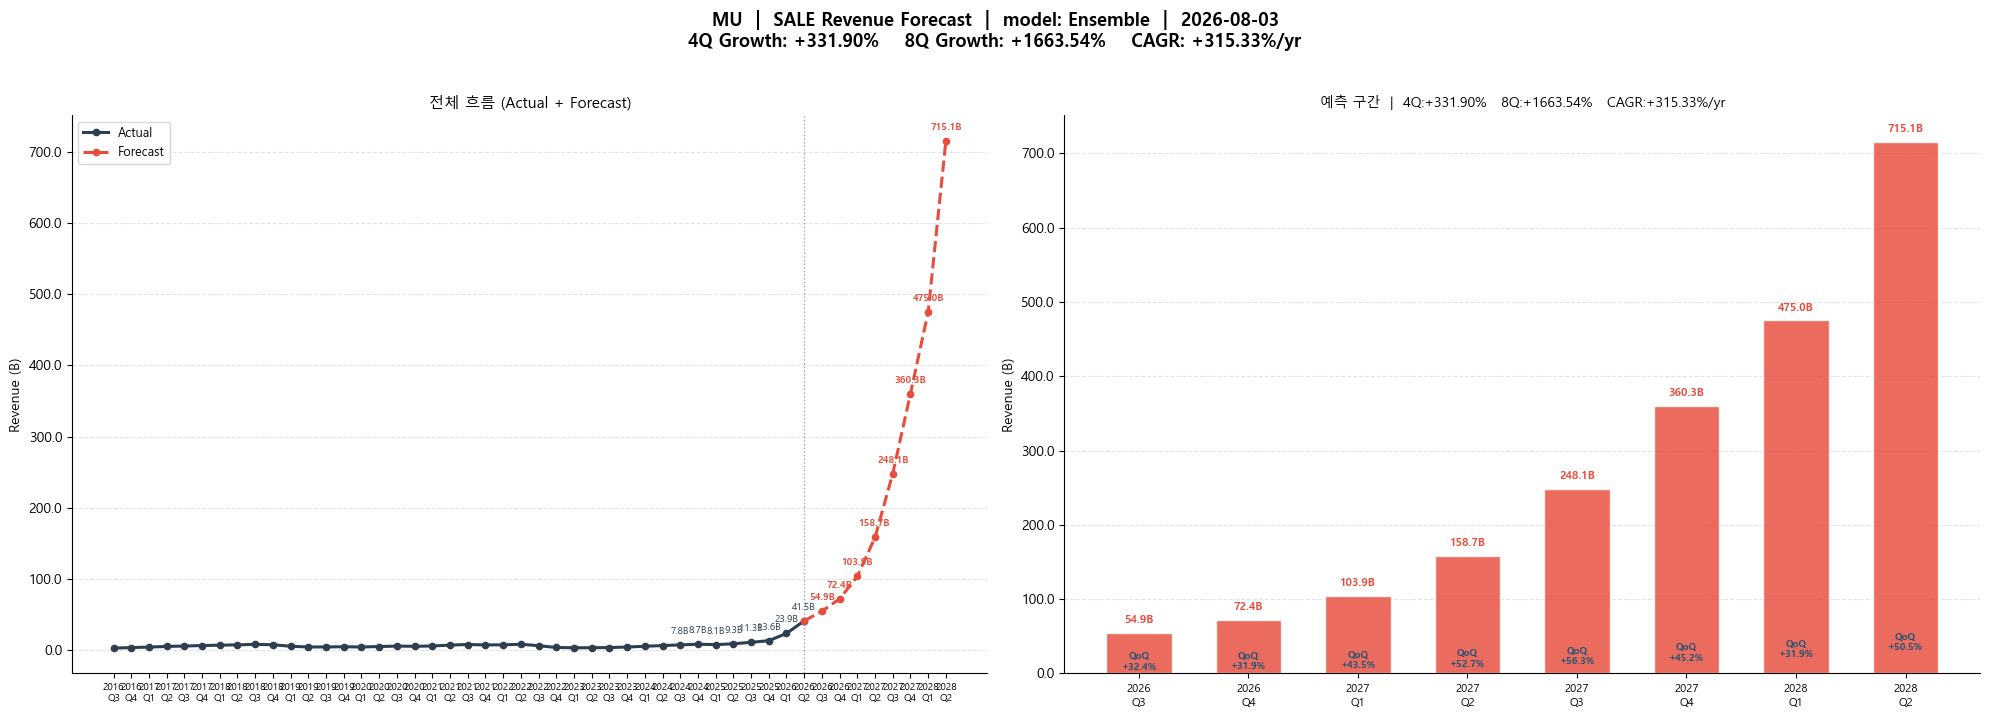

In [7]:
def plot_ticker_forecast(ticker: str, model: str = MODEL, item: str = ITEM,
                         forecast_date: Optional[str] = None,
                         figsize: tuple = (20, 7), save_path: Optional[str] = None):
    """단일 티커 actual + forecast 시각화 (Line + Bar)"""
    res = fetch_forecast(ticker, model, item, forecast_date)
    act, fc, gdf = res["actual_df"], res["forecast_df"], res["growth_df"]

    div, unit = unit_divisor(max(act["value"].max(), fc["value"].max()))
    act_v, fc_v = (act["value"] / div).tolist(), (fc["value"] / div).tolist()
    act_lbl, fc_lbl = [qtr_label(d) for d in act["date"]], [qtr_label(d) for d in fc["date"]]

    g4_s = f"{res['growth_4q']:+.2f}%"     if res["growth_4q"]  is not None else "N/A"
    g8_s = f"{res['growth_8q']:+.2f}%"     if res["growth_8q"]  is not None else "N/A"
    ca_s = f"{res['cagr_total']:+.2f}%/yr" if res["cagr_total"] is not None else "N/A"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f"{ticker}  |  {item.upper()} Revenue Forecast  |  model: {model}  |  {res['forecast_date']}\n"
                 f"4Q Growth: {g4_s}    8Q Growth: {g8_s}    CAGR: {ca_s}",
                 fontsize=13, fontweight="bold", y=1.02)

    split, all_v, all_lbl = len(act_v), act_v + fc_v, act_lbl + fc_lbl

    # (1) Line
    ax1.plot(range(split), act_v, color=ACTUAL_COLOR, lw=2.2, marker="o", ms=4.5, label="Actual", zorder=3)
    ax1.plot(range(split - 1, len(all_v)), all_v[split - 1:], color=FORECAST_COLOR, lw=2.2, ls="--",
             marker="o", ms=4.5, label="Forecast", zorder=3)
    ax1.axvline(x=split - 1, color="gray", lw=1.0, ls=":", alpha=0.7)
    show_set = set(range(max(0, split - 8), split)) | set(range(split, len(all_v)))
    for i, v in enumerate(all_v):
        if i in show_set:
            ax1.annotate(f"{v:.1f}{unit}", (i, v), xytext=(0, 8), textcoords="offset points",
                         ha="center", fontsize=7, color=ACTUAL_COLOR if i < split else FORECAST_COLOR,
                         fontweight="bold" if i >= split else "normal")
    ax1.set_xticks(range(len(all_lbl))); ax1.set_xticklabels(all_lbl, fontsize=7)
    ax1.set_title("전체 흐름 (Actual + Forecast)", fontsize=11)
    ax1.set_ylabel(f"Revenue ({unit})", fontsize=10); ax1.legend(fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax1.grid(axis="y", ls="--", alpha=0.35); ax1.spines[["top", "right"]].set_visible(False)

    # (2) Bar (예측 구간)
    x = list(range(len(fc_v)))
    bars = ax2.bar(x, fc_v, color=FORECAST_COLOR, alpha=0.82, width=0.6, edgecolor="white", zorder=2)
    for i, (bar, v) in enumerate(zip(bars, fc_v)):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(fc_v) * 0.013, f"{v:.1f}{unit}",
                 ha="center", va="bottom", fontsize=8, fontweight="bold", color=FORECAST_COLOR)
        qoq = gdf["QoQ(%)"].iloc[i]
        if pd.notna(qoq):
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.04, f"QoQ\n{qoq:+.1f}%",
                     ha="center", va="bottom", fontsize=7, fontweight="bold",
                     color="#1A5276" if qoq >= 0 else "#922B21")
    ax2.set_xticks(x); ax2.set_xticklabels(fc_lbl, fontsize=8)
    ax2.set_title(f"예측 구간  |  4Q:{g4_s}   8Q:{g8_s}   CAGR:{ca_s}", fontsize=10)
    ax2.set_ylabel(f"Revenue ({unit})", fontsize=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax2.grid(axis="y", ls="--", alpha=0.35); ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        log("CHART", f"저장 → {save_path}")
    plt.show()
    return res


_png = (os.path.join(OUTPUT_DIR, f"{CHART_TICKER}_revenue_forecast_{date.today():%Y%m%d}.png")
        if SAVE_CHARTS else None)
plot_ticker_forecast(CHART_TICKER, MODEL, save_path=_png);


## Cell 8 · 전체 종목 조회 · TTM 성장률 계산 · 전체 순위

```
revenue_ttm          = Σ 직전 실제 4분기
revenue_forecast_sum = Σ Q+1 ~ Q+4 (예측)
yoy_growth           = revenue_forecast_sum / revenue_ttm − 1
rank                 = 전체 유효 종목 기준 yoy_growth 내림차순
```
`FORECAST_DATES=None` 이면 티커별 최신 `forecast_date` 를 사용하므로, 어닝 시점이 달라 예측일이 서로 다른 종목도 모두 포함됩니다.


In [8]:
def load_forecast_raw(model: str = MODEL,
                      item: str = ITEM,
                      forecast_dates=FORECAST_DATES) -> pd.DataFrame:
    """
    actual + forecast 원시 행을 한 번에 조회.
    - forecast_dates None → 티커별 MAX(forecast_date)
    - list             → 해당 날짜들만, 티커별 최신만 유지
    반환 컬럼: ticker, date, value, forecast_date, model, data_type
    """
    if forecast_dates is None:
        sql = f"""
            SELECT f.ticker, f.date, f.value, f.forecast_date, f.model, f.data_type
            FROM {SRC_TABLE} f
            JOIN (
                SELECT ticker, MAX(forecast_date) AS fd
                FROM {SRC_TABLE}
                WHERE item=%s AND model=%s AND data_type='forecast'
                GROUP BY ticker
            ) m ON f.ticker = m.ticker AND f.forecast_date = m.fd
            WHERE f.item=%s
              AND ( (f.model=%s AND f.data_type='forecast') OR f.model='actual' )
            ORDER BY f.ticker, f.date
        """
        params = (item, model, item, model)
    else:
        dl = [str(d) for d in (forecast_dates if isinstance(forecast_dates, (list, tuple)) else [forecast_dates])]
        ph = ", ".join(["%s"] * len(dl))
        sql = f"""
            SELECT ticker, date, value, forecast_date, model, data_type
            FROM {SRC_TABLE}
            WHERE item=%s
              AND forecast_date IN ({ph})
              AND ( (model=%s AND data_type='forecast') OR model='actual' )
            ORDER BY ticker, forecast_date DESC, date
        """
        params = tuple([item] + dl + [model])

    raw = query_df(sql, params)
    if raw.empty:
        raise ValueError(f"model='{model}' item='{item}' 데이터가 없습니다.")

    raw["date"]          = pd.to_datetime(raw["date"])
    raw["forecast_date"] = pd.to_datetime(raw["forecast_date"])
    raw["value"]         = raw["value"].astype(float)

    if forecast_dates is not None:
        # 티커별 최신 forecast_date 만 유지 (ORDER BY forecast_date DESC 이므로 first = 최신)
        latest = raw[raw["data_type"] == "forecast"].groupby("ticker")["forecast_date"].max()
        raw = raw.merge(latest.rename("fd_keep"), left_on="ticker", right_index=True, how="inner")
        raw = raw[raw["forecast_date"] == raw["fd_keep"]].drop(columns="fd_keep")

    log("LOAD", f"rows={len(raw):,}  tickers={raw['ticker'].nunique():,}  "
                f"forecast_dates={sorted(raw['forecast_date'].dt.strftime('%Y-%m-%d').unique().tolist())[-5:]} ...")
    return raw


def build_growth_table(raw: pd.DataFrame,
                       unit_div: float = UNIT_DIVISOR,
                       min_rev_ttm: float = MIN_REVENUE_TTM,
                       exclude: List[str] = EXCLUDE_TICKERS,
                       require_consecutive: bool = REQUIRE_CONSECUTIVE) -> Dict[str, pd.DataFrame]:
    """
    티커별 TTM / Q+1~Q+4 / Forward-TTM / yoy_growth 계산 후 전체 순위 부여.
    Returns {"summary": df, "detail": df, "excluded": df}
    """
    exclude = set(t.upper() for t in (exclude or []))
    rows, dropped = [], []

    for tk, g in raw.groupby("ticker", sort=True):
        act = g[g["model"] == "actual"].sort_values("date")
        fc  = g[(g["model"] != "actual") & (g["data_type"] == "forecast")].sort_values("date")
        act_v, fc_v = act["value"].tolist(), fc["value"].tolist()

        reason = None
        if tk.upper() in exclude:              reason = "EXCLUDE_TICKERS"
        elif len(act_v) < 4:                   reason = f"actual<4 ({len(act_v)})"
        elif len(fc_v) < 4:                    reason = f"forecast<4 ({len(fc_v)})"
        else:
            ttm = float(np.sum(act_v[-4:]))
            if ttm <= 0:                       reason = "revenue_ttm<=0"
            elif ttm < min_rev_ttm:            reason = f"revenue_ttm<{min_rev_ttm:,.0f}"

        gap_m  = _months_between(act["date"].iloc[-1], fc["date"].iloc[0]) if (len(act_v) and len(fc_v)) else None
        gap_ok = gap_m is not None and 2 <= gap_m <= 4
        if reason is None and require_consecutive and not gap_ok:
            reason = f"gap_flag (last_actual→Q+1 = {gap_m}개월)"

        if reason is not None:
            dropped.append({"ticker": tk, "reason": reason,
                            "n_actual": len(act_v), "n_forecast": len(fc_v)})
            continue

        ttm  = float(np.sum(act_v[-4:]))
        q    = fc_v[:4]
        fsum = float(np.sum(q))
        yoy  = fsum / ttm - 1.0

        g8 = None
        if len(act_v) >= 8 and len(fc_v) >= 8:
            b8 = float(np.sum(act_v[-8:]))
            g8 = (float(np.sum(fc_v[:8])) / b8 - 1.0) if b8 > 0 else None
        cagr = calc_cagr(act_v[-1], fc_v[-1], len(fc_v))        # %/yr
        cagr = cagr / 100.0 if cagr is not None else None       # 소수로 통일

        rows.append({
            "ticker"               : tk,
            "company_name"         : "",                      # Cell 5 에서 채움
            "forecast_date"        : fc["forecast_date"].max().date(),
            "revenue_ttm"          : ttm  / unit_div,
            "Q+1"                  : q[0] / unit_div,
            "Q+2"                  : q[1] / unit_div,
            "Q+3"                  : q[2] / unit_div,
            "Q+4"                  : q[3] / unit_div,
            "revenue_forecast_sum" : fsum / unit_div,
            "yoy_growth"           : yoy,                     # 소수 (Excel 에서 % 서식)
            # ── detail 전용 ──
            "last_actual_quarter"  : _qlabel(act["date"].iloc[-1]),
            "Q+1_quarter"          : _qlabel(fc["date"].iloc[0]),
            "Q+4_quarter"          : _qlabel(fc["date"].iloc[3]),
            "growth_8q"            : g8,
            "cagr_total"           : cagr,
            "n_actual_q"           : len(act_v),
            "n_forecast_q"         : len(fc_v),
            "gap_months"           : gap_m,
            "gap_flag"             : "" if gap_ok else "CHECK",
            "model"                : MODEL,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("유효 종목이 없습니다. 필터/데이터를 확인하세요.")

    # ── 전체 순위 (yoy_growth 내림차순, 동률은 같은 순위) ─────────────
    df["rank"] = df["yoy_growth"].rank(ascending=False, method="min").astype(int)
    df = df.sort_values(["rank", "ticker"]).reset_index(drop=True)
    df["n_total"] = len(df)

    SUMMARY_COLS = ["rank", "ticker", "company_name", "forecast_date", "revenue_ttm",
                    "Q+1", "Q+2", "Q+3", "Q+4", "revenue_forecast_sum", "yoy_growth"]
    DETAIL_COLS  = SUMMARY_COLS + ["n_total", "last_actual_quarter", "Q+1_quarter", "Q+4_quarter",
                                   "growth_8q", "cagr_total", "n_actual_q", "n_forecast_q",
                                   "gap_months", "gap_flag", "model"]

    excluded = pd.DataFrame(dropped, columns=["ticker", "reason", "n_actual", "n_forecast"])
    log("CALC", f"유효 {len(df):,} 종목 / 제외 {len(excluded):,} 종목")
    if not excluded.empty:
        print(excluded["reason"].str.split(" ").str[0].value_counts().to_string())

    return {"summary": df[SUMMARY_COLS].copy(),
            "detail" : df[DETAIL_COLS].copy(),
            "excluded": excluded}

print("[OK] load_forecast_raw / build_growth_table 정의 완료")


[OK] load_forecast_raw / build_growth_table 정의 완료


## Cell 9 · 회사명 매핑 (FMP profile + 로컬 CSV 캐시)

미국 DB에는 회사명이 없으므로 FMP `/profile` 로 조회합니다. 결과는 출력 폴더의 `_fmp_profile_cache.csv` 에 저장되어 이후 실행에서는 API 호출 없이 재사용됩니다.

In [9]:
_PROFILE_COLS = ["ticker", "company_name", "sector", "industry", "exchange", "mkt_cap", "fetched_at"]

def _load_profile_cache() -> pd.DataFrame:
    if os.path.exists(PROFILE_CACHE_PATH):
        try:
            c = pd.read_csv(PROFILE_CACHE_PATH, dtype={"ticker": str}, encoding="utf-8-sig")
            for col in _PROFILE_COLS:
                if col not in c.columns:
                    c[col] = np.nan
            c["ticker"] = c["ticker"].str.upper()
            return c[_PROFILE_COLS]
        except Exception as e:
            log("CACHE", f"캐시 로드 실패({e}) → 새로 생성")
    return pd.DataFrame(columns=_PROFILE_COLS)

def _save_profile_cache(c: pd.DataFrame):
    c.drop_duplicates("ticker", keep="last").to_csv(PROFILE_CACHE_PATH, index=False, encoding="utf-8-sig")

def _parse_profile(d: dict) -> dict:
    return {
        "company_name": d.get("companyName") or "",
        "sector"      : d.get("sector") or "",
        "industry"    : d.get("industry") or "",
        "exchange"    : d.get("exchangeShortName") or d.get("exchange") or "",
        "mkt_cap"     : d.get("mktCap") or d.get("marketCap"),
    }

def _fmp_get(url: str, params: dict):
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code == 429:
            log("FMP", "429 rate limit → 20초 대기")
            time.sleep(20)
            r = requests.get(url, params=params, timeout=15)
        data = r.json()
        return data if isinstance(data, list) else []
    except Exception as e:
        return []

def fetch_company_names(tickers: List[str], verbose: bool = True) -> pd.DataFrame:
    """
    캐시에 없거나 오래된 티커만 FMP 에서 조회 → 캐시 갱신 → 전체 매핑 반환.
    1) v3 /profile/A,B,C (배치)  2) 누락분 /stable/profile?symbol=X (단건)
    """
    tickers = [str(t).upper() for t in dict.fromkeys(tickers)]
    cache = _load_profile_cache()

    if not FETCH_COMPANY_NAME:
        return cache

    cutoff = pd.Timestamp.now() - pd.Timedelta(days=PROFILE_CACHE_MAX_AGE_DAYS)
    fresh  = cache[(pd.to_datetime(cache["fetched_at"], errors="coerce") >= cutoff)
                   & cache["company_name"].fillna("").ne("")]["ticker"].tolist()
    miss   = [t for t in tickers if t not in set(fresh)]
    if verbose:
        log("NAME", f"대상 {len(tickers):,} / 캐시 적중 {len(tickers)-len(miss):,} / 조회 필요 {len(miss):,}")
    if not miss:
        return cache

    now_s, new_rows = datetime.now().strftime("%Y-%m-%d"), []
    for i in range(0, len(miss), FMP_BATCH):
        batch = miss[i:i + FMP_BATCH]
        got = set()
        for d in _fmp_get(f"{FMP_BASE_V3}/profile/{','.join(batch)}", {"apikey": FMP_API_KEY}):
            sym = str(d.get("symbol", "")).upper()
            if sym:
                new_rows.append({"ticker": sym, **_parse_profile(d), "fetched_at": now_s})
                got.add(sym)
        time.sleep(FMP_SLEEP)
        for t in batch:                          # 단건 fallback (stable)
            if t in got:
                continue
            data = _fmp_get(f"{FMP_BASE_ST}/profile", {"symbol": t, "apikey": FMP_API_KEY})
            if data:
                new_rows.append({"ticker": t, **_parse_profile(data[0]), "fetched_at": now_s})
            else:
                new_rows.append({"ticker": t, "company_name": "", "sector": "", "industry": "",
                                 "exchange": "", "mkt_cap": np.nan, "fetched_at": now_s})
            time.sleep(FMP_SLEEP)
        if verbose and (i // FMP_BATCH) % 10 == 0:
            log("NAME", f"  진행 {min(i+FMP_BATCH, len(miss)):,}/{len(miss):,}")

    if new_rows:
        cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
        cache = cache.drop_duplicates("ticker", keep="last")
        _save_profile_cache(cache)
        n_ok = sum(1 for r in new_rows if r["company_name"])
        log("NAME", f"신규 조회 {len(new_rows):,} (성공 {n_ok:,}) → 캐시 저장: {PROFILE_CACHE_PATH}")
    return cache


def attach_company_names(tables: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    """summary/detail 의 company_name 채우고 detail 에 sector/industry/mkt_cap($B) 추가."""
    prof = fetch_company_names(tables["summary"]["ticker"].tolist())
    if prof.empty:
        return tables
    m = prof.set_index("ticker")
    for key in ("summary", "detail"):
        df = tables[key]
        df["company_name"] = df["ticker"].str.upper().map(m["company_name"]).fillna("")
    d = tables["detail"]
    d["sector"]    = d["ticker"].str.upper().map(m["sector"]).fillna("")
    d["industry"]  = d["ticker"].str.upper().map(m["industry"]).fillna("")
    d["mkt_cap_$B"]= pd.to_numeric(d["ticker"].str.upper().map(m["mkt_cap"]), errors="coerce") / 1e9
    return tables

print("[OK] fetch_company_names / attach_company_names 정의 완료")


[OK] fetch_company_names / attach_company_names 정의 완료


## Cell 10 · Excel 저장 함수

시트 구성: **Summary**(요청 형식) · **Detail**(분기 라벨·8Q 성장률·CAGR·섹터·시총) · **Excluded**(제외 종목·사유) · **Meta**(생성 정보·정의)

값은 수식이 아닌 **숫자 값**으로 기록합니다 (pandas 로 재로딩해 유튜브 콘텐츠 제작 시 수식 미계산 문제 방지).

In [10]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

_HDR_FILL  = PatternFill("solid", fgColor="1F3864")
_HDR_FONT  = Font(name="Arial", bold=True, color="FFFFFF", size=10)
_BODY_FONT = Font(name="Arial", size=10)
_THIN      = Side(style="thin", color="D9D9D9")
_BORDER    = Border(bottom=_THIN)

_MONEY_FMT = "#,##0.00"
_PCT_FMT   = "0.00%"
_INT_FMT   = "#,##0"

def _write_df(ws, df: pd.DataFrame, money_cols=(), pct_cols=(), int_cols=(), date_cols=(),
              gradient_col: Optional[str] = None, widths: Optional[dict] = None):
    ws.append(list(df.columns))
    for c in ws[1]:
        c.fill, c.font = _HDR_FILL, _HDR_FONT
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    ws.row_dimensions[1].height = 22

    for row in df.itertuples(index=False):
        ws.append([None if (isinstance(v, float) and np.isnan(v)) else v for v in row])

    n_rows, n_cols = len(df), len(df.columns)
    col_idx = {c: i + 1 for i, c in enumerate(df.columns)}
    for name, fmt in [*[(c, _MONEY_FMT) for c in money_cols],
                      *[(c, _PCT_FMT)   for c in pct_cols],
                      *[(c, _INT_FMT)   for c in int_cols],
                      *[(c, "yyyy-mm-dd") for c in date_cols]]:
        if name in col_idx:
            L = get_column_letter(col_idx[name])
            for cell in ws[f"{L}2:{L}{n_rows+1}"]:
                cell[0].number_format = fmt
    for row in ws.iter_rows(min_row=2, max_row=n_rows + 1, max_col=n_cols):
        for cell in row:
            cell.font, cell.border = _BODY_FONT, _BORDER

    if gradient_col and gradient_col in col_idx and n_rows > 1:
        L = get_column_letter(col_idx[gradient_col])
        ws.conditional_formatting.add(
            f"{L}2:{L}{n_rows+1}",
            ColorScaleRule(start_type="min", start_color="F8696B",
                           mid_type="percentile", mid_value=50, mid_color="FFFFFF",
                           end_type="max", end_color="63BE7B"))

    default_w = {"ticker": 10, "company_name": 34, "forecast_date": 13, "rank": 7}
    for c, i in col_idx.items():
        w = (widths or {}).get(c, default_w.get(c, 14))
        ws.column_dimensions[get_column_letter(i)].width = w
    ws.freeze_panes = "C2" if "company_name" in col_idx else "A2"
    ws.auto_filter.ref = f"A1:{get_column_letter(n_cols)}{n_rows+1}"


def save_growth_excel(tables: Dict[str, pd.DataFrame],
                      report_date: Optional[date] = None,
                      out_dir: str = OUTPUT_DIR) -> str:
    report_date = report_date or date.today()
    fname = f"{FILE_PREFIX}_{report_date.strftime('%Y%m%d')}.xlsx"
    path  = os.path.join(out_dir, fname)

    s, d, x = tables["summary"], tables["detail"], tables["excluded"]
    money = ["revenue_ttm", "Q+1", "Q+2", "Q+3", "Q+4", "revenue_forecast_sum"]

    wb = Workbook()
    ws = wb.active; ws.title = "Summary"
    _write_df(ws, s, money_cols=money, pct_cols=["yoy_growth"], int_cols=["rank"],
              date_cols=["forecast_date"], gradient_col="yoy_growth")

    ws2 = wb.create_sheet("Detail")
    _write_df(ws2, d, money_cols=money + ["mkt_cap_$B"], pct_cols=["yoy_growth", "growth_8q", "cagr_total"],
              int_cols=["rank", "n_total", "n_actual_q", "n_forecast_q", "gap_months"],
              date_cols=["forecast_date"], gradient_col="yoy_growth",
              widths={"sector": 22, "industry": 30})

    ws3 = wb.create_sheet("Excluded")
    _write_df(ws3, x if not x.empty else pd.DataFrame(columns=["ticker", "reason", "n_actual", "n_forecast"]),
              int_cols=["n_actual", "n_forecast"], widths={"reason": 40})

    ws4 = wb.create_sheet("Meta")
    fds = pd.to_datetime(s["forecast_date"])
    meta = [
        ("report_date",            report_date.isoformat()),
        ("generated_at",           datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("source_table",           SRC_TABLE),
        ("item / model",           f"{ITEM} / {MODEL}"),
        ("forecast_date_mode",     "티커별 최신" if FORECAST_DATES is None else str(FORECAST_DATES)),
        ("forecast_date_range",    f"{fds.min().date()} ~ {fds.max().date()}"),
        ("unit",                   f"{UNIT_LABEL} (원값 ÷ {UNIT_DIVISOR:,.0f})"),
        ("n_valid / n_excluded",   f"{len(s):,} / {len(x):,}"),
        ("MIN_REVENUE_TTM ($)",    f"{MIN_REVENUE_TTM:,.0f}"),
        ("REQUIRE_CONSECUTIVE",    str(REQUIRE_CONSECUTIVE)),
        ("EXCLUDE_TICKERS",        ", ".join(EXCLUDE_TICKERS) or "-"),
        ("", ""),
        ("정의: revenue_ttm",           "직전 실제 4분기 매출 합산"),
        ("정의: Q+1~Q+4",               "향후 4개 분기 매출 예측치 (모델 = " + MODEL + ")"),
        ("정의: revenue_forecast_sum",  "Q+1~Q+4 합산 (Forward TTM)"),
        ("정의: yoy_growth",            "revenue_forecast_sum / revenue_ttm − 1"),
        ("정의: rank",                  "전체 유효 종목 기준 yoy_growth 내림차순 (동률 = 같은 순위)"),
        ("정의: growth_8q",             "Σ 예측 8Q / Σ 최근 실제 8Q − 1"),
        ("정의: cagr_total",            "(예측 마지막값 / 실제 마지막값)^(4/예측분기수) − 1  (연환산)"),
        ("정의: gap_flag",              "마지막 실제분기 → Q+1 간격이 2~4개월 범위 밖이면 CHECK"),
        ("주의",                        "시계열 모델은 M&A·가이던스 수정 등 구조적 단절을 반영하지 못함 → 상위 종목은 개별 검토 필요"),
    ]
    ws4.append(["항목", "값"])
    for c in ws4[1]:
        c.fill, c.font = _HDR_FILL, _HDR_FONT
    for k, v in meta:
        ws4.append([k, v])
    ws4.column_dimensions["A"].width = 30
    ws4.column_dimensions["B"].width = 90
    for row in ws4.iter_rows(min_row=2):
        for cell in row:
            cell.font = _BODY_FONT

    wb.save(path)
    log("SAVE", f"저장 완료 → {path}")
    return path

print("[OK] save_growth_excel 정의 완료")


[OK] save_growth_excel 정의 완료


## Cell 11 · 실행 — 추출 → 회사명 → 저장 → 미리보기

In [11]:
# 1) 데이터 조회 + 성장률/순위 계산
raw    = load_forecast_raw(model=MODEL, item=ITEM, forecast_dates=FORECAST_DATES)
tables = build_growth_table(raw)

# 2) 회사명 (FMP profile, 캐시 우선)
tables = attach_company_names(tables)

# 3) Excel 저장 : {OUTPUT_DIR}\us_revenue_growth_analysis_{YYYYMMDD}.xlsx
xlsx_path = save_growth_excel(tables)

# 4) 미리보기 (Summary 상위 PREVIEW_N)
summary_df = tables["summary"]

print(f"\n[매출 성장 종합평가]  model={MODEL}  단위={UNIT_LABEL}  유효 {len(summary_df):,} 종목  "
      f"(상위 {PREVIEW_N} 미리보기)\n")

money_cols = ["revenue_ttm", "Q+1", "Q+2", "Q+3", "Q+4", "revenue_forecast_sum"]
display(
    summary_df.head(PREVIEW_N).style
        .format({**{c: "{:,.2f}" for c in money_cols}, "yoy_growth": "{:+.2%}"})
        .background_gradient(subset=["yoy_growth"], cmap="YlGn")
        .set_caption(f"US Revenue Growth — Top {PREVIEW_N} by Forward-TTM YoY  ({xlsx_path})")
        .pipe(_hide_idx)
)


[16:14:22][LOAD] rows=89,586  tickers=1,868  forecast_dates=['2026-05-01', '2026-05-28', '2026-06-25', '2026-08-03', '2026-08-20'] ...
[16:14:26][CALC] 유효 1,840 종목 / 제외 28 종목
reason
revenue_ttm<=0    28
[16:14:28][SAVE] 저장 완료 → C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가\us_revenue_growth_analysis_20260831.xlsx

[매출 성장 종합평가]  model=Ensemble  단위=$M  유효 1,840 종목  (상위 30 미리보기)



rank,ticker,company_name,forecast_date,revenue_ttm,Q+1,Q+2,Q+3,Q+4,revenue_forecast_sum,yoy_growth
1,CMRX,,2026-08-03,0.21,2.02,1.95,2.50,4.10,10.57,+4884.92%
2,QURE,,2026-08-03,18.67,4.06,25.32,3.39,187.96,220.73,+1082.13%
3,PLOW,,2026-08-03,"215,132.46","213,378.63","319,531.51","425,659.60","531,842.21","1,490,411.95",+592.79%
4,CLDX,,2026-08-03,0.82,0.07,0.79,2.29,0.73,3.88,+373.20%
5,QUBT,,2026-08-03,4.33,3.56,4.33,5.18,5.82,18.89,+335.88%
6,MU,,2026-08-03,"90,274.00","54,901.66","72,400.20","103,906.30","158,687.03","389,895.19",+331.90%
7,TGTX,,2026-08-03,700.35,237.93,349.24,295.50,"1,859.36","2,742.03",+291.52%
8,CZR,,2026-08-03,"11,648.00","9,338.68","9,372.77","10,381.55","12,813.65","41,906.65",+259.78%
9,SUPN,,2026-08-03,"219,669.38","137,855.33","164,122.94","207,823.19","226,254.67","736,056.13",+235.07%
10,AMN,,2026-08-03,"3,419.26","1,826.69","2,195.68","2,908.82","4,280.88","11,212.07",+227.91%


## Cell 12 · Best-N 추출 + 4Q/8Q 성장률 비교 막대 차트

`get_best_n(tables, n, sort_by)` : Cell 11 결과(`tables["detail"]`)에서 상위 N 추출 — DB 재조회 없음  
**위 패널** 향후 4분기 누적 성장률 / **아래 패널** 향후 8분기 누적 성장률



[매출 성장률 Top-30]  model=Ensemble  기준=4Q  forecast_date=2026-05-28 ~ 2026-08-03



,ticker,company_name,forecast_date,act_sum_4q,fc_sum_4q,growth_4q_pct,growth_8q_pct,cagr_total_pct,rank_all
1,CMRX,,2026-08-03,0.21,10.57,+4884.92%,+3905.64%,+619.09%/yr,1
2,QURE,,2026-08-03,18.67,220.73,+1082.13%,+705.64%,-26.00%/yr,2
3,PLOW,,2026-08-03,"215,132.46","1,490,411.95",+592.79%,+2069.18%,+111.09%/yr,3
4,CLDX,,2026-08-03,0.82,3.88,+373.20%,-15.51%,+331.97%/yr,4
5,QUBT,,2026-08-03,4.33,18.89,+335.88%,+964.50%,+56.58%/yr,5
6,MU,,2026-08-03,"90,274.00","389,895.19",+331.90%,+1663.54%,+315.33%/yr,6
7,TGTX,,2026-08-03,700.35,"2,742.03",+291.52%,+1646.07%,+353.03%/yr,7
8,CZR,,2026-08-03,"11,648.00","41,906.65",+259.78%,+316.12%,+119.00%/yr,8
9,SUPN,,2026-08-03,"219,669.38","736,056.13",+235.07%,+842.25%,+37.46%/yr,9
10,AMN,,2026-08-03,"3,419.26","11,212.07",+227.91%,+853.11%,+287.18%/yr,10


[16:14:29][CHART] 저장 → C:\Users\82108\OneDrive\INVESTMENT\미국주식\매출성장_종합평가\best30_4q_growth_20260831.png


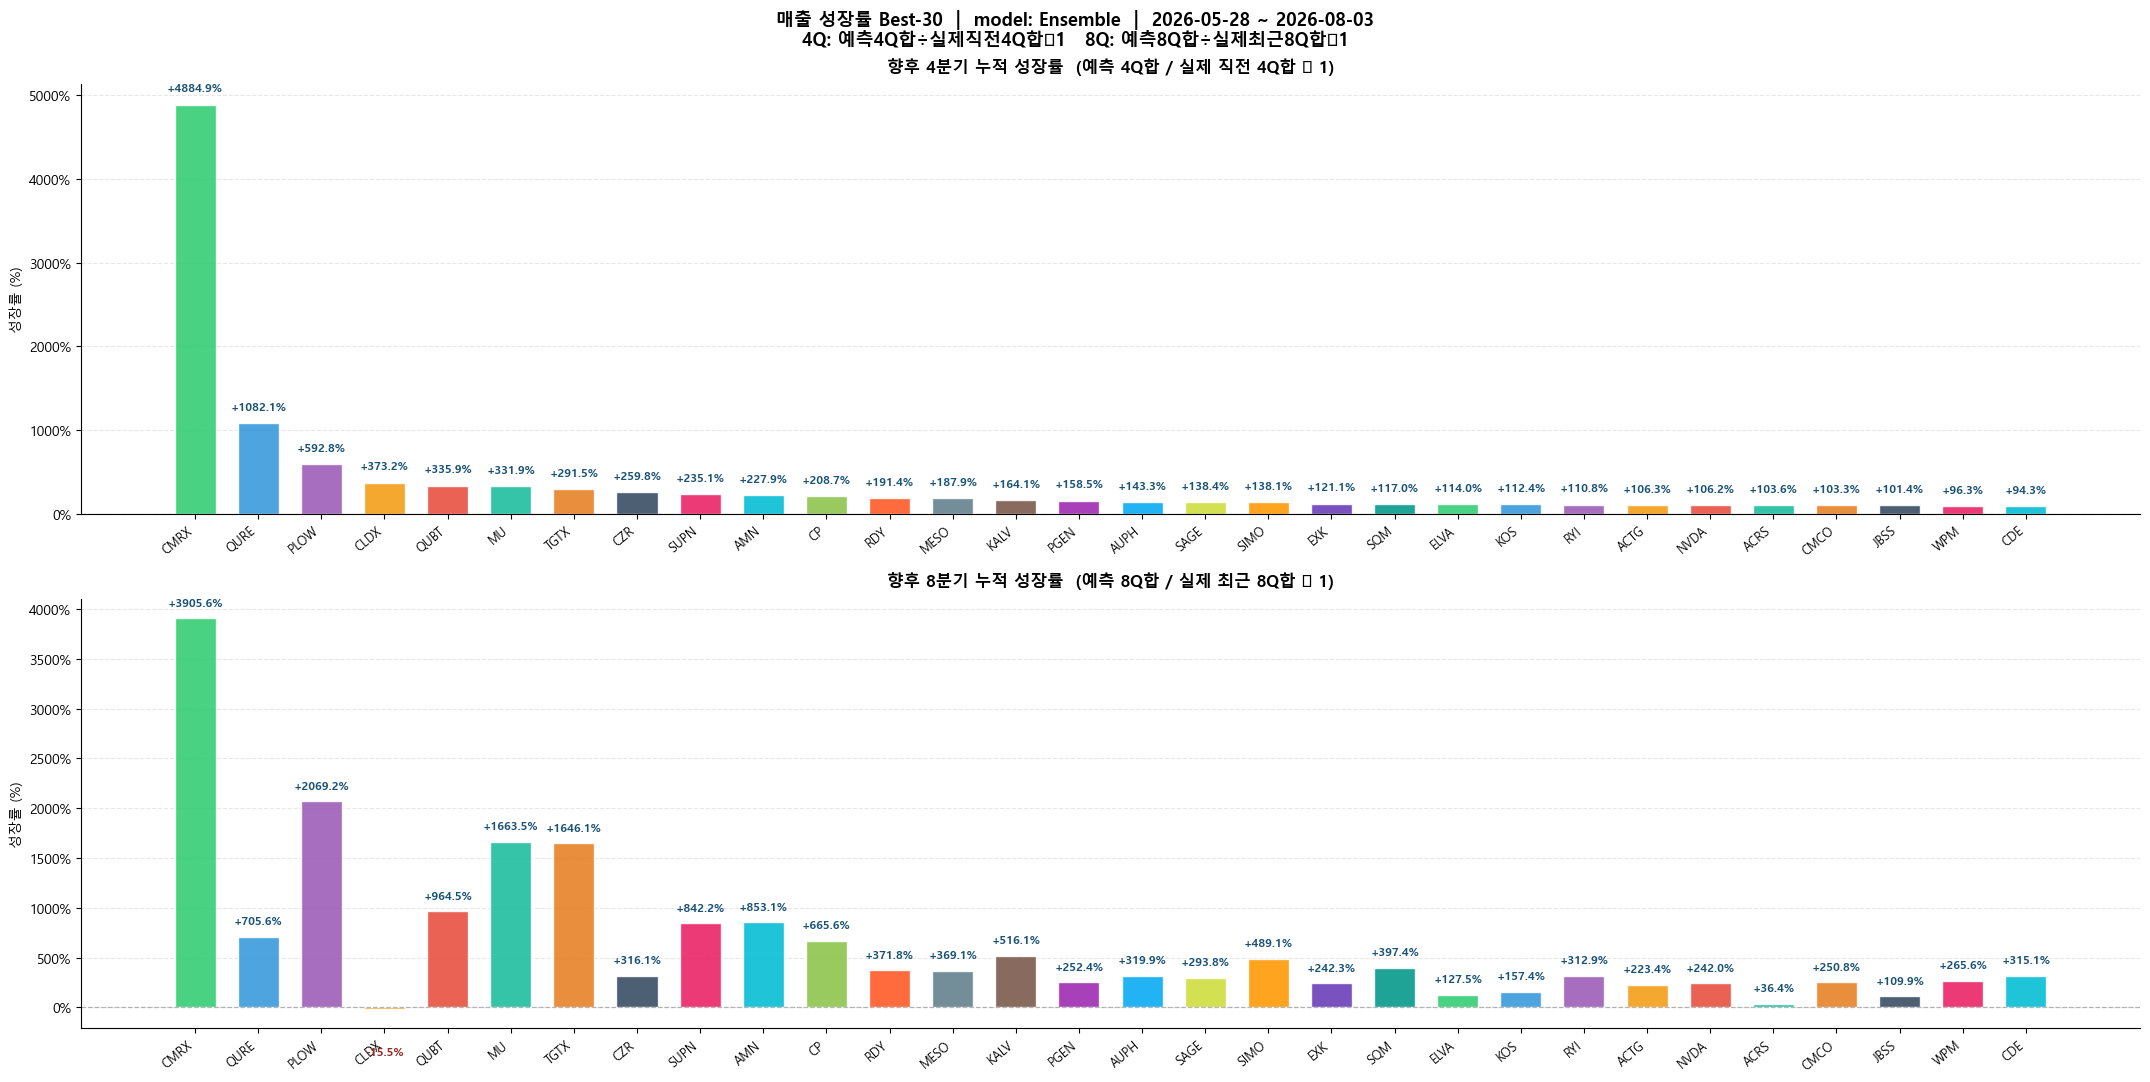

In [12]:
def get_best_n(tables: Dict[str, pd.DataFrame], n: int = BEST_N, sort_by: str = BEST_SORTBY) -> pd.DataFrame:
    """전체 순위 테이블에서 상위 N. 반환 컬럼은 기존 get_best_n 과 동일(% 단위)."""
    if sort_by not in ("4q", "8q"):
        raise ValueError("sort_by 는 '4q' 또는 '8q' 이어야 합니다.")
    d = tables["detail"]
    out = pd.DataFrame({
        "ticker"        : d["ticker"],
        "company_name"  : d["company_name"],
        "forecast_date" : d["forecast_date"],
        "act_sum_4q"    : d["revenue_ttm"],
        "fc_sum_4q"     : d["revenue_forecast_sum"],
        "growth_4q_pct" : d["yoy_growth"] * 100,
        "growth_8q_pct" : d["growth_8q"]  * 100,
        "cagr_total_pct": d["cagr_total"] * 100,
        "rank_all"      : d["rank"],
    })
    sort_col = "growth_4q_pct" if sort_by == "4q" else "growth_8q_pct"
    out = (out.dropna(subset=[sort_col]).sort_values(sort_col, ascending=False)
              .head(n).reset_index(drop=True))
    out.index += 1
    return out


def plot_best_n_growth(best_df: pd.DataFrame, model: str = MODEL, forecast_date: str = "",
                       top_n: Optional[int] = None, w_per_bar: float = 0.72,
                       save_path: Optional[str] = None):
    """Best-N 기업의 4Q / 8Q 성장률 상하 2패널 비교 차트"""
    df = best_df.head(top_n).copy() if top_n else best_df.copy()
    tickers, n = df["ticker"].tolist(), len(df)
    colors = (BAR_PALETTE * 5)[:n]

    has_4q, has_8q = df["growth_4q_pct"].notna().any(), df["growth_8q_pct"].notna().any()
    n_pnl = int(has_4q) + int(has_8q)
    if n_pnl == 0:
        print("[WARN] 성장률 데이터가 없습니다."); return

    fig, axes = plt.subplots(n_pnl, 1, figsize=(max(14, n * w_per_bar), 5.5 * n_pnl))
    axes = [axes] if n_pnl == 1 else list(axes)
    fig.suptitle(f"매출 성장률 Best-{n}  |  model: {model}  |  {forecast_date}\n"
                 "4Q: 예측4Q합÷실제직전4Q합−1   8Q: 예측8Q합÷실제최근8Q합−1",
                 fontsize=13, fontweight="bold")

    def _draw(ax, raw_vals, title):
        vals = [v if pd.notna(v) else 0 for v in raw_vals]
        mx   = max(abs(v) for v in vals) if vals else 1
        bars = ax.bar(range(n), vals, color=colors, alpha=0.88, width=0.65, edgecolor="white", zorder=2)
        for bar, v, orig in zip(bars, vals, raw_vals):
            if pd.isna(orig):
                continue
            off  = mx * 0.025
            ypos = bar.get_height() + (off if v >= 0 else -off * 3.8)
            ax.text(bar.get_x() + bar.get_width() / 2, ypos, f"{v:+.1f}%",
                    ha="center", va="bottom" if v >= 0 else "top", fontsize=8.5, fontweight="bold",
                    color="#1A5276" if v >= 0 else "#922B21")
        ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.55)
        ax.set_xticks(range(n)); ax.set_xticklabels(tickers, rotation=40, ha="right", fontsize=9)
        ax.set_ylabel("성장률 (%)", fontsize=10)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.grid(axis="y", ls="--", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)

    pi = 0
    if has_4q:
        _draw(axes[pi], df["growth_4q_pct"].tolist(), "향후 4분기 누적 성장률  (예측 4Q합 / 실제 직전 4Q합 − 1)"); pi += 1
    if has_8q:
        _draw(axes[pi], df["growth_8q_pct"].tolist(), "향후 8분기 누적 성장률  (예측 8Q합 / 실제 최근 8Q합 − 1)")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        log("CHART", f"저장 → {save_path}")
    plt.show()


# ── 실행 ──────────────────────────────────────────────────────────────
best_df = get_best_n(tables, n=BEST_N, sort_by=BEST_SORTBY)
_fds    = pd.to_datetime(best_df["forecast_date"])
_fd_str = f"{_fds.min():%Y-%m-%d} ~ {_fds.max():%Y-%m-%d}" if _fds.min() != _fds.max() else f"{_fds.min():%Y-%m-%d}"

print(f"\n[매출 성장률 Top-{BEST_N}]  model={MODEL}  기준={BEST_SORTBY.upper()}  forecast_date={_fd_str}\n")
display(
    best_df.style
        .format({"act_sum_4q": "{:,.2f}", "fc_sum_4q": "{:,.2f}",
                 "growth_4q_pct": "{:+.2f}%", "growth_8q_pct": "{:+.2f}%", "cagr_total_pct": "{:+.2f}%/yr"},
                na_rep="-")
        .background_gradient(subset=["growth_4q_pct", "growth_8q_pct"], cmap="YlGn")
        .set_caption(f"매출 성장률 Top-{BEST_N} ({MODEL}, 정렬: {BEST_SORTBY.upper()}, 단위: {UNIT_LABEL})")
)

_png = (os.path.join(OUTPUT_DIR, f"best{BEST_N}_{BEST_SORTBY}_growth_{date.today():%Y%m%d}.png")
        if SAVE_CHARTS else None)
plot_best_n_growth(best_df, model=MODEL, forecast_date=_fd_str, save_path=_png)


## Cell 13 · 특정 종목 순위 확인

`CHECK_TICKERS` 에 관심 종목을 넣으면 전체 순위와 성장률을 바로 확인합니다.

In [13]:
CHECK_TICKERS = ["LLY", "NVDA", "MU"]     # ← 변경

chk = summary_df[summary_df["ticker"].str.upper().isin([t.upper() for t in CHECK_TICKERS])]
if chk.empty:
    print("해당 종목이 Summary 에 없습니다 (Excluded 시트 확인).")
else:
    display(
        chk.style
           .format({**{c: "{:,.2f}" for c in money_cols}, "yoy_growth": "{:+.2%}"})
           .pipe(_hide_idx)
    )
    print(f"전체 {len(summary_df):,} 종목 중 순위")


rank,ticker,company_name,forecast_date,revenue_ttm,Q+1,Q+2,Q+3,Q+4,revenue_forecast_sum,yoy_growth
6,MU,,2026-08-03,"90,274.00","54,901.66","72,400.20","103,906.30","158,687.03","389,895.19",+331.90%
25,NVDA,,2026-08-03,"253,491.00","101,129.27","121,061.49","139,190.36","161,272.52","522,653.64",+106.18%
146,LLY,,2026-08-20,"79,665.80","24,115.40","26,568.85","26,487.90","29,225.74","106,397.89",+33.56%


전체 1,840 종목 중 순위
